In [2]:
from google.colab import files

print("Upload files:")
uploaded = files.upload()

Upload files:


Saving X_test_sequences.npy to X_test_sequences (1).npy
Saving X_train_sequences.npy to X_train_sequences (1).npy
Saving y_true_binary.npy to y_true_binary (1).npy


In [3]:
import numpy as np

X_train_sequences = np.load('X_train_sequences.npy')
X_test_sequences = np.load('X_test_sequences.npy')
y_true_binary = np.load('y_true_binary.npy')

# Chronological 80/20 split
split_idx = int(len(X_train_sequences) * 0.8)
X_train_fit = X_train_sequences[:split_idx]
X_val = X_train_sequences[split_idx:]

print("=== Data Loaded ===")
print(f"X_train_fit : {X_train_fit.shape}")
print(f"X_val       : {X_val.shape}")
print(f"X_test      : {X_test_sequences.shape}")
print(f"y_true      : {y_true_binary.shape}")

=== Data Loaded ===
X_train_fit : (2870, 10, 128)
X_val       : (718, 10, 128)
X_test      : (5122, 10, 128)
y_true      : (5122,)


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, RepeatVector,
                                     TimeDistributed, Dense,
                                     MultiHeadAttention, LayerNormalization,
                                     Add)
from tensorflow.keras.callbacks import EarlyStopping

seq_length = 10
feature_dim = 128

# ── BUILD MODEL ────────────────────────────────────────────────────
inputs = Input(shape=(seq_length, feature_dim), name="Temporal_Input")

# ENCODER
x = LSTM(64, activation='tanh', return_sequences=True,
         name="Encoder_LSTM_1")(inputs)
encoded = LSTM(32, activation='tanh', return_sequences=True,
               name="Encoder_Bottleneck")(x)

# ATTENTION over encoded sequence
attention_out = MultiHeadAttention(
    num_heads=4,
    key_dim=8,
    name="Temporal_Attention"
)(encoded, encoded)

# Residual connection + normalization
attention_out = Add(name="Residual_Add")([attention_out, encoded])
attention_out = LayerNormalization(name="Layer_Norm")(attention_out)

# Take last timestep as bottleneck
bottleneck = attention_out[:, -1, :]
repeated = RepeatVector(seq_length, name="Bridge_Repeater")(bottleneck)

# DECODER
x = LSTM(32, activation='tanh', return_sequences=True,
         name="Decoder_LSTM_1")(repeated)
x = LSTM(64, activation='tanh', return_sequences=True,
         name="Decoder_LSTM_2")(x)
outputs = TimeDistributed(Dense(feature_dim),
                          name="Reconstruction_Output")(x)

lstm_attention = Model(inputs, outputs, name="LSTM_Attention_Autoencoder")
lstm_attention.compile(optimizer='adam', loss='mse')
lstm_attention.summary()

# ── TRAIN ──────────────────────────────────────────────────────────
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining LSTM + Attention Autoencoder...")
history = lstm_attention.fit(
    X_train_fit, X_train_fit,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping],
    verbose=1
)

Model: "LSTM_Attention_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Temporal_Input      │ (None, 10, 128)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_LSTM_1      │ (None, 10, 64)    │     49,408 │ Temporal_Input[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_Bottleneck  │ (None, 10, 32)    │     12,416 │ Encoder_LSTM_1[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Temporal_Attention  │ (None, 10, 32)    │      4,224 │ Encoder_Bottlene… │
│ (MultiHeadAttentio… │                   │            │ Encoder_Bottlene… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Add (Add)  │ (None, 10, 32)    │          0 │ Temporal_Attenti… │
│                     │                   │            │ Encoder_Bottlene… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Layer_Norm          │ (None, 10, 32)    │         64 │ Residual_Add[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 32)        │          0 │ Layer_Norm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Bridge_Repeater     │ (None, 10, 32)    │          0 │ get_item[0][0]    │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_LSTM_1      │ (None, 10, 32)    │      8,320 │ Bridge_Repeater[… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_LSTM_2      │ (None, 10, 64)    │     24,832 │ Decoder_LSTM_1[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Reconstruction_Out… │ (None, 10, 128)   │      8,320 │ Decoder_LSTM_2[0… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 107,584 (420.25 KB)

 Trainable params: 107,584 (420.25 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM + Attention Autoencoder...
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 9.9979e-04 - val_loss: 1.2769e-04
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.0370e-05 - val_loss: 5.4204e-05
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.5935e-05 - val_loss: 3.5756e-05
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.9968e-05 - val_loss: 2.7986e-05
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.2461e-05 - val_loss: 2.4003e-05
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 8.4083e-06 - val_loss: 2.1928e-05
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.9934e-06 - val_loss: 2.0512e-05
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.4498e-06 - val_loss: 1.9592e-05
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.4087e-06 - val_loss: 1.9067e-05
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2.6752e-06 - val_loss: 1.8653e-05
Epoch 11/50
45/45 ━━━━━━━━━

In [5]:
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# 1. Threshold calibration on validation set
val_reconstructions = lstm_attention.predict(X_val, verbose=0)
val_mse = np.mean(np.square(X_val - val_reconstructions), axis=(1, 2))
mean_val_mse = np.mean(val_mse)
std_val_mse = np.std(val_mse)

print(f"Validation MSE — Mean: {mean_val_mse:.8f} | Std: {std_val_mse:.8f}")

# 2. Score full test set
test_reconstructions = lstm_attention.predict(X_test_sequences, verbose=0)
test_mse = np.mean(np.square(X_test_sequences - test_reconstructions), axis=(1, 2))
test_anomaly_scores = np.abs(test_mse - mean_val_mse)

# 3. Invert scores
inverted_scores = -test_anomaly_scores

# 4. ROC AUC
roc_auc = roc_auc_score(y_true_binary, inverted_scores)
print(f"\nLSTM + Attention ROC AUC: {roc_auc:.4f}")

# 5. Optimal threshold via Youden's J
fpr, tpr, thresholds = roc_curve(y_true_binary, inverted_scores)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

y_pred = (inverted_scores > optimal_threshold).astype(int)

print(f"Optimal Threshold: {optimal_threshold:.6e}")
print("\nClassification Report:")
print(classification_report(
    y_true_binary, y_pred,
    target_names=["Normal (0)", "Anomaly (1)"],
    zero_division=0
))

Validation MSE — Mean: 0.00001730 | Std: 0.00001066

LSTM + Attention ROC AUC: 0.9017
Optimal Threshold: -1.707466e-05

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.84      0.83      0.84      2496
 Anomaly (1)       0.84      0.85      0.85      2626

    accuracy                           0.84      5122
   macro avg       0.84      0.84      0.84      5122
weighted avg       0.84      0.84      0.84      5122



ABLATION STUDY — SPATIOTEMPORAL WEAPON ANOMALY DETECTION
Model                                  AUC    Acc   N-F1   A-F1     Params  Epochs
-------------------------------------------------------------------------------------
Untrained CNN + LSTM                0.4434   0.70   0.21   0.82    103,296      20
Trained CNN + LSTM                  0.8850   0.84   0.83   0.85    103,296      16
Trained CNN + GRU                   0.9084   0.84   0.84   0.85     80,128      24
Trained CNN + LSTM + Attention      0.9017   0.84   0.84   0.85    107,584      29
Trained CNN + Dense (No Temporal)   0.9221   0.84   0.83   0.84     20,768       7
N-F1 = Normal class F1 | A-F1 = Anomaly class F1


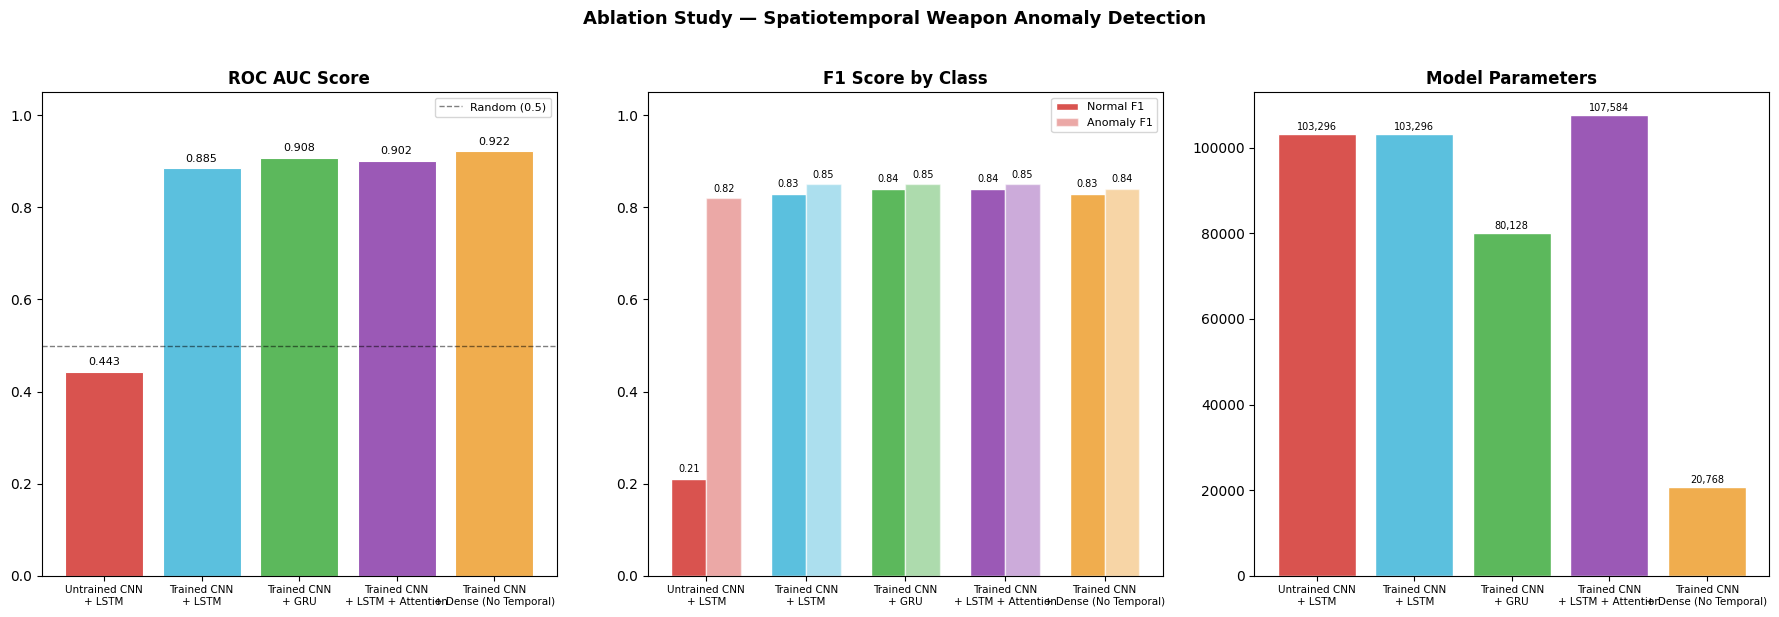


Saved as ablation_study_final.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── All results ────────────────────────────────────────────────────
models = [
    "Untrained CNN\n+ LSTM",
    "Trained CNN\n+ LSTM",
    "Trained CNN\n+ GRU",
    "Trained CNN\n+ LSTM + Attention",
    "Trained CNN\n+ Dense (No Temporal)"
]

auc        = [0.4434, 0.8850, 0.9084, 0.9017, 0.9221]
accuracy   = [0.70,   0.84,   0.84,   0.84,   0.84  ]
normal_f1  = [0.21,   0.83,   0.84,   0.84,   0.83  ]
anomaly_f1 = [0.82,   0.85,   0.85,   0.85,   0.84  ]
params     = [103296, 103296, 80128,  107584, 20768  ]
epochs     = [20,     16,     24,     29,     7      ]

# ── Print table ────────────────────────────────────────────────────
print("=" * 85)
print("ABLATION STUDY — SPATIOTEMPORAL WEAPON ANOMALY DETECTION")
print("=" * 85)
header = f"{'Model':<35} {'AUC':>6} {'Acc':>6} {'N-F1':>6} {'A-F1':>6} {'Params':>10} {'Epochs':>7}"
print(header)
print("-" * 85)

labels = [
    "Untrained CNN + LSTM",
    "Trained CNN + LSTM",
    "Trained CNN + GRU",
    "Trained CNN + LSTM + Attention",
    "Trained CNN + Dense (No Temporal)",
]

for i in range(len(labels)):
    print(f"{labels[i]:<35} {auc[i]:>6.4f} {accuracy[i]:>6.2f} "
          f"{normal_f1[i]:>6.2f} {anomaly_f1[i]:>6.2f} "
          f"{params[i]:>10,} {epochs[i]:>7}")

print("=" * 85)
print("N-F1 = Normal class F1 | A-F1 = Anomaly class F1")

# ── Chart ──────────────────────────────────────────────────────────
colors = ['#d9534f', '#5bc0de', '#5cb85c', '#9b59b6', '#f0ad4e']
x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Ablation Study — Spatiotemporal Weapon Anomaly Detection",
             fontsize=13, fontweight='bold', y=1.02)

# AUC plot
bars = axes[0].bar(x, auc, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title("ROC AUC Score", fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=7.5)
axes[0].axhline(y=0.5, color='black', linestyle='--',
                linewidth=1, alpha=0.5, label='Random (0.5)')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, auc):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.3f}", ha='center', va='bottom', fontsize=8)

# F1 grouped bar
bars1 = axes[1].bar(x - width/2, normal_f1, width,
                    color=colors, edgecolor='white', label='Normal F1')
bars2 = axes[1].bar(x + width/2, anomaly_f1, width,
                    color=colors, edgecolor='white', alpha=0.5, label='Anomaly F1')
axes[1].set_title("F1 Score by Class", fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=7.5)
axes[1].legend(fontsize=8)
for bar, val in zip(bars1, normal_f1):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.2f}", ha='center', va='bottom', fontsize=7)
for bar, val in zip(bars2, anomaly_f1):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.2f}", ha='center', va='bottom', fontsize=7)

# Parameters plot
bars3 = axes[2].bar(x, params, color=colors, edgecolor='white')
axes[2].set_title("Model Parameters", fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, fontsize=7.5)
for bar, val in zip(bars3, params):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f"{val:,}", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig("ablation_study_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as ablation_study_final.png")

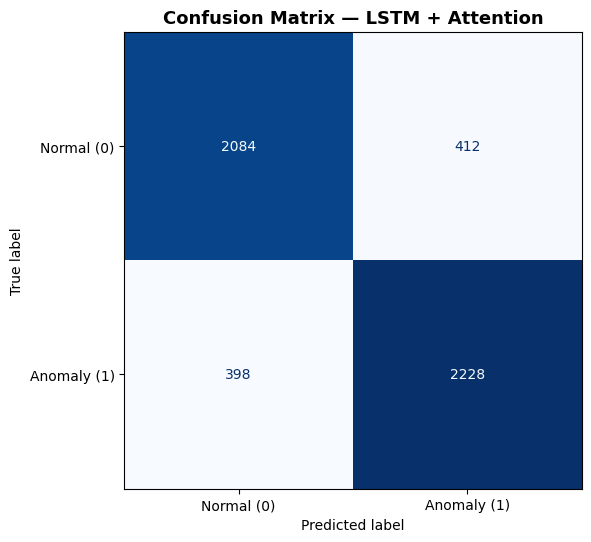

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_binary, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal (0)", "Anomaly (1)"]
)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', colorbar=False)

plt.title("Confusion Matrix — LSTM + Attention", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix_lstm_attention.png", dpi=150, bbox_inches='tight')
plt.show()